# 3D姿勢分類：歩行 vs 歩きスマホ

MediaPipe BlazePoseから抽出した3D骨格キーポイントを使用して、普通の歩行と歩きスマホの分類を行います。

## 目標
- 3D正規化骨格キーポイント（x, y, z座標）を特徴量として使用
- scikit-learnのランダムフォレストで二値分類モデルを構築
- データ分析、モデル評価、特徴量重要度の可視化

## データセット
- **walk**: 普通の歩行
- **phone**: 歩きスマホ
- 各サンプル: 33個のキーポイント × 3座標（x, y, z）= 99特徴量

In [13]:
# 必要なライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# プロットの設定
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("ライブラリのインポート完了")

ライブラリのインポート完了


In [14]:
# データの読み込み
data_path = '/home/eevee/depthai_blazepose/data/plot/pose_landmarks_3d_normalized.csv'
df = pd.read_csv(data_path)

print(f"データセット形状: {df.shape}")
print(f"\n列数: {len(df.columns)}")
print(f"\nクラス分布:")
print(df['class'].value_counts())
print(f"\n欠損値の確認:")
print(df.isnull().sum().sum())

# 基本統計情報
print(f"\nデータセットの基本情報:")
print(f"- 総サンプル数: {len(df)}")
print(f"- 特徴量数: {len(df.columns) - 3}")
print(f"- クラス数: {df['class'].nunique()}")

# 最初の数行を表示
print(f"\nデータの最初の3行:")
df.head(3)

データセット形状: (304, 135)

列数: 135

クラス分布:
class
phone    183
walk     121
Name: count, dtype: int64

欠損値の確認:
0

データセットの基本情報:
- 総サンプル数: 304
- 特徴量数: 132
- クラス数: 2

データの最初の3行:


,scene,image,class,x1,y1,z1,v1,x2,y2,z2,...,z31,v31,x32,y32,z32,v32,x33,y33,z33,v33
0,clark-center-2019-02-28_1,868,phone,-0.171013,-0.704249,-0.163706,0.999583,-0.148710,-0.731446,-0.187912,...,0.180458,0.576145,-0.091981,0.991267,-0.094497,0.938098,0.009507,0.908806,0.164570,0.619500
1,clark-center-2019-02-28_1,1214,phone,0.022482,-0.622004,-0.314414,0.995779,0.042228,-0.646019,-0.308444,...,0.149369,0.871317,0.230790,0.963806,0.133467,0.977304,-0.208085,0.886865,0.065331,0.946519
2,clark-center-2019-02-28_1,948,phone,-0.065891,-0.679199,-0.334108,0.999106,-0.046874,-0.704743,-0.331119,...,0.332478,0.866791,0.089168,0.995468,0.033043,0.976560,-0.213082,0.893629,0.275580,0.910037


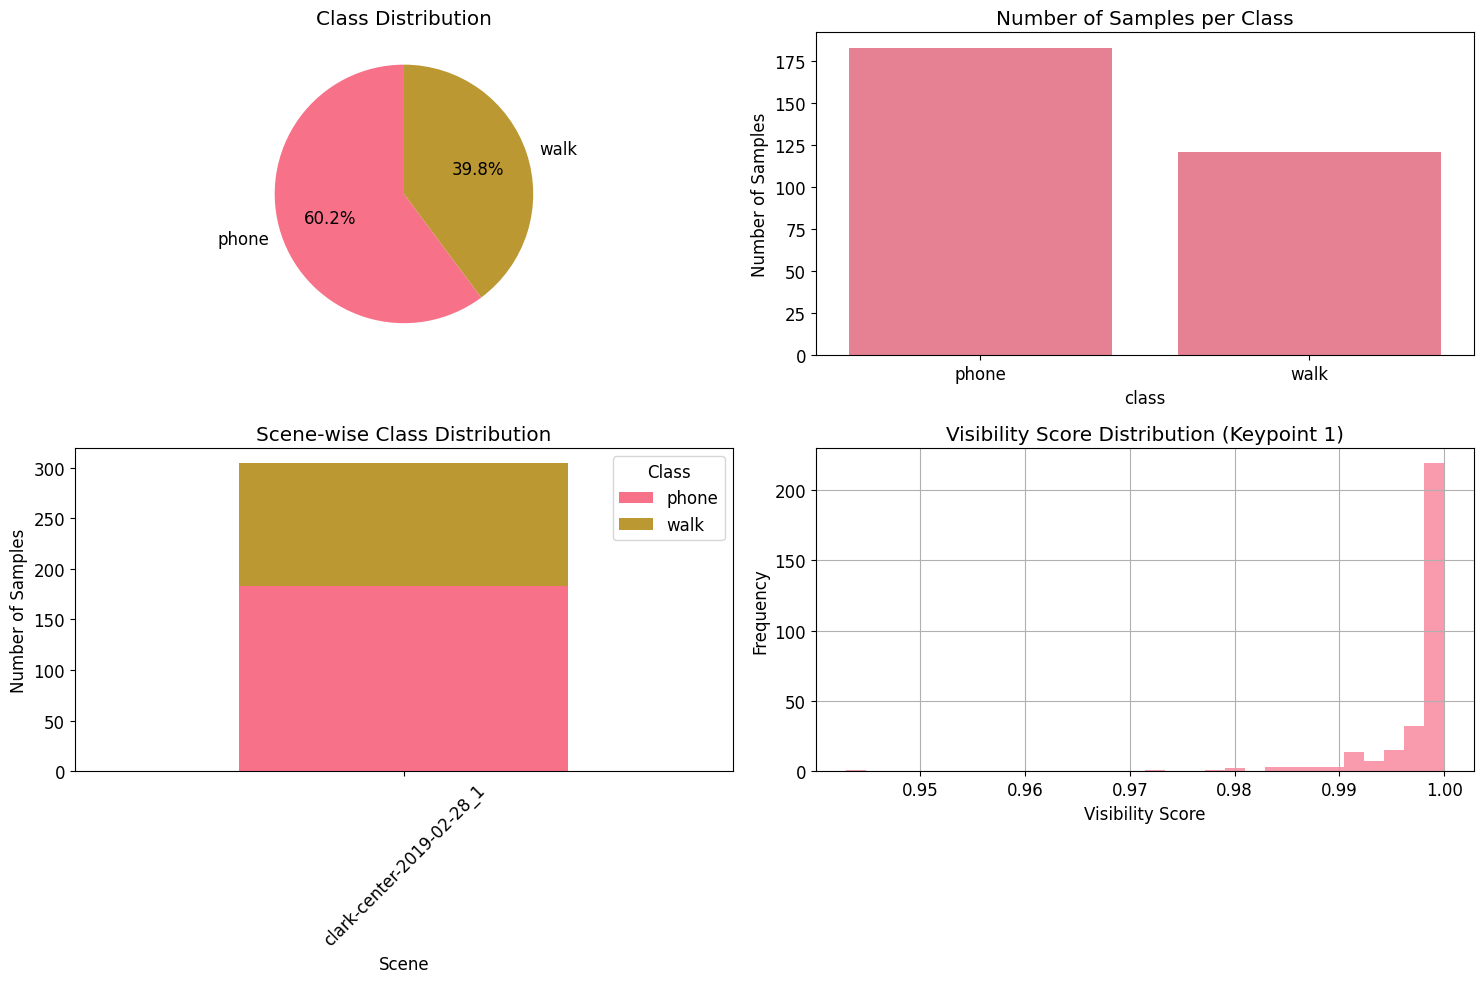


Class Details:
- phone: 183 samples, 1 scenes
- walk: 121 samples, 1 scenes


In [15]:
# Class distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Class distribution
class_counts = df['class'].value_counts()
axes[0, 0].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Class Distribution')

# 2. Number of samples per class
sns.countplot(data=df, x='class', ax=axes[0, 1])
axes[0, 1].set_title('Number of Samples per Class')
axes[0, 1].set_ylabel('Number of Samples')

# 3. Scene-wise class distribution
scene_class = df.groupby(['scene', 'class']).size().unstack(fill_value=0)
scene_class.plot(kind='bar', stacked=True, ax=axes[1, 0])
axes[1, 0].set_title('Scene-wise Class Distribution')
axes[1, 0].set_xlabel('Scene')
axes[1, 0].set_ylabel('Number of Samples')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Class')

# 4. Visibility score distribution (example: v1)
df['v1'].hist(bins=30, alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('Visibility Score Distribution (Keypoint 1)')
axes[1, 1].set_xlabel('Visibility Score')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"\nClass Details:")
for class_name in df['class'].unique():
    count = df[df['class'] == class_name].shape[0]
    scenes = df[df['class'] == class_name]['scene'].nunique()
    print(f"- {class_name}: {count} samples, {scenes} scenes")

In [16]:
# 特徴量とターゲットの準備
# メタデータ列を除く（scene, image, class）
feature_columns = [col for col in df.columns if col not in ['scene', 'image', 'class']]
print(f"特徴量数: {len(feature_columns)}")

# 特徴量の種類を確認
coord_features = [col for col in feature_columns if col.startswith(('x', 'y', 'z'))]
visibility_features = [col for col in feature_columns if col.startswith('v')]

print(f"座標特徴量: {len(coord_features)}")
print(f"可視性特徴量: {len(visibility_features)}")

# 特徴量行列X
X = df[feature_columns].values
print(f"特徴量行列形状: {X.shape}")

# ターゲット変数y
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['class'])
print(f"ターゲット変数形状: {y.shape}")
print(f"クラスマッピング: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# 特徴量の基本統計
print(f"\n特徴量の基本統計:")
print(f"平均値の範囲: [{X.mean(axis=0).min():.4f}, {X.mean(axis=0).max():.4f}]")
print(f"標準偏差の範囲: [{X.std(axis=0).min():.4f}, {X.std(axis=0).max():.4f}]")
print(f"最小値: {X.min():.4f}")
print(f"最大値: {X.max():.4f}")

特徴量数: 132
座標特徴量: 99
可視性特徴量: 33
特徴量行列形状: (304, 132)
ターゲット変数形状: (304,)
クラスマッピング: {'phone': 0, 'walk': 1}

特徴量の基本統計:
平均値の範囲: [-0.7279, 0.9999]
標準偏差の範囲: [0.0002, 0.3866]
最小値: -0.9567
最大値: 1.0000


=== データ分割結果 ===
全体データ: 304サンプル
学習データ: 243サンプル (79.9%)
テストデータ: 61サンプル (20.1%)

=== 学習データのクラス分布 ===
phone: 146サンプル (60.1%)
walk: 97サンプル (39.9%)

=== テストデータのクラス分布 ===
phone: 37サンプル (60.7%)
walk: 24サンプル (39.3%)


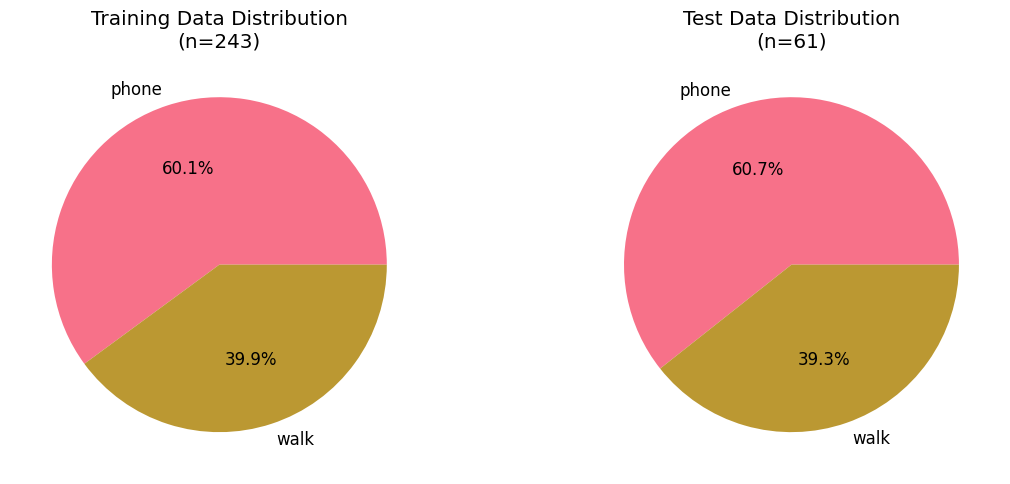

In [17]:
# データの分割（学習用とテスト用）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=== データ分割結果 ===")
print(f"全体データ: {X.shape[0]}サンプル")
print(f"学習データ: {X_train.shape[0]}サンプル ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"テストデータ: {X_test.shape[0]}サンプル ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

# クラス別データ数の確認
print(f"\n=== 学習データのクラス分布 ===")
train_labels = label_encoder.inverse_transform(y_train)
for class_name in label_encoder.classes_:
    count = np.sum(train_labels == class_name)
    print(f"{class_name}: {count}サンプル ({count/len(y_train)*100:.1f}%)")

print(f"\n=== テストデータのクラス分布 ===")
test_labels = label_encoder.inverse_transform(y_test)
for class_name in label_encoder.classes_:
    count = np.sum(test_labels == class_name)
    print(f"{class_name}: {count}サンプル ({count/len(y_test)*100:.1f}%)")

# 分割の可視化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 学習データ
train_counts = pd.Series(train_labels).value_counts()
ax1.pie(train_counts.values, labels=train_counts.index, autopct='%1.1f%%')
ax1.set_title(f'Training Data Distribution\n(n={len(y_train)})')

# テストデータ
test_counts = pd.Series(test_labels).value_counts()
ax2.pie(test_counts.values, labels=test_counts.index, autopct='%1.1f%%')
ax2.set_title(f'Test Data Distribution\n(n={len(y_test)})')

plt.tight_layout()
plt.show()

=== 特徴量スケーリング完了 ===
スケーリング前 - 平均: 0.1464, 標準偏差: 0.5311
スケーリング後 - 平均: 0.0000, 標準偏差: 1.0000


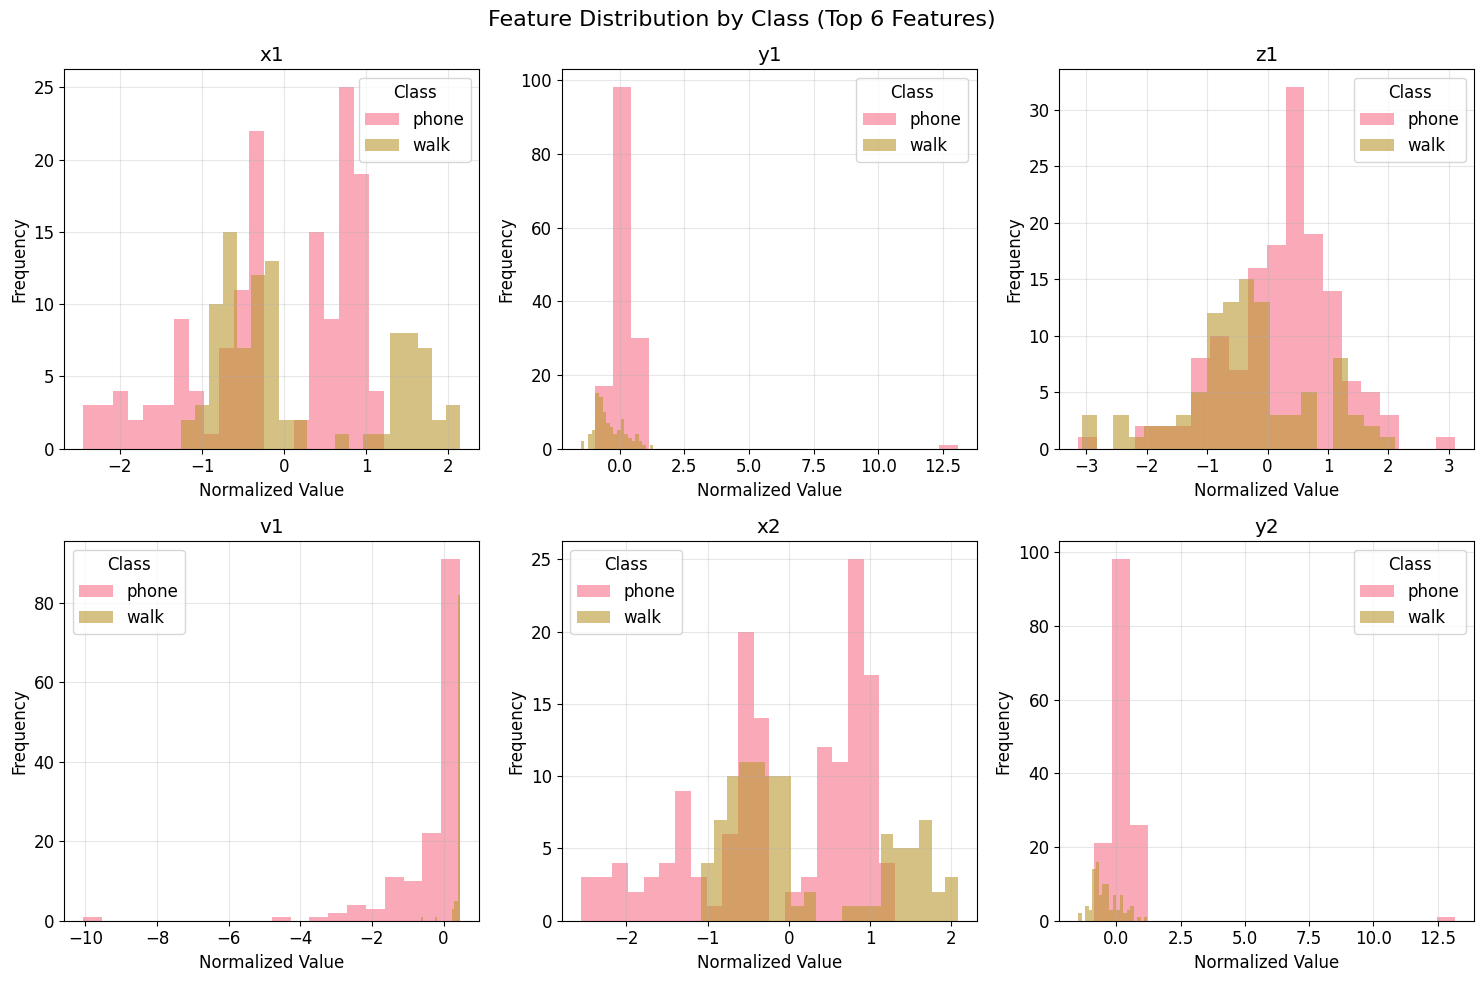

In [18]:
# 特徴量のスケーリング（標準化）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== 特徴量スケーリング完了 ===")
print(f"スケーリング前 - 平均: {X_train.mean():.4f}, 標準偏差: {X_train.std():.4f}")
print(f"スケーリング後 - 平均: {X_train_scaled.mean():.4f}, 標準偏差: {X_train_scaled.std():.4f}")

# 特徴量の分布を可視化（最初の6つの特徴量）
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i in range(6):
    feature_name = feature_columns[i]
    
    # クラス別の特徴量分布
    for class_idx, class_name in enumerate(label_encoder.classes_):
        mask = y_train == class_idx
        axes[i].hist(X_train_scaled[mask, i], alpha=0.6, label=class_name, bins=20)
    
    axes[i].set_title(f'{feature_name}')
    axes[i].set_xlabel('Normalized Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(title='Class')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Feature Distribution by Class (Top 6 Features)', fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
# ランダムフォレストモデルの訓練
print("=== ランダムフォレストモデルの訓練 ===")

# ベースラインモデル
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_scaled, y_train)

# ベースラインモデルの評価
y_pred_baseline = rf_baseline.predict(X_test_scaled)
y_pred_proba_baseline = rf_baseline.predict_proba(X_test_scaled)[:, 1]

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_auc = roc_auc_score(y_test, y_pred_proba_baseline)

print(f"ベースラインモデル:")
print(f"- 精度: {baseline_accuracy:.4f}")
print(f"- AUC: {baseline_auc:.4f}")

# ハイパーパラメータチューニング
print(f"\nハイパーパラメータチューニング実行中...")
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n最適パラメータ: {grid_search.best_params_}")
print(f"最適CV精度: {grid_search.best_score_:.4f}")

# 最適モデル
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
y_pred_proba_best = best_rf.predict_proba(X_test_scaled)[:, 1]

best_accuracy = accuracy_score(y_test, y_pred_best)
best_auc = roc_auc_score(y_test, y_pred_proba_best)

print(f"\n最適化モデル:")
print(f"- 精度: {best_accuracy:.4f}")
print(f"- AUC: {best_auc:.4f}")
print(f"- 改善: {best_accuracy - baseline_accuracy:.4f}")

=== ランダムフォレストモデルの訓練 ===
ベースラインモデル:
- 精度: 0.9508
- AUC: 0.9944

ハイパーパラメータチューニング実行中...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

最適パラメータ: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
最適CV精度: 0.9876

最適化モデル:
- 精度: 0.9508
- AUC: 0.9932
- 改善: 0.0000


=== モデル評価結果 ===

Classification Report:
              precision    recall  f1-score   support

       phone       0.97      0.95      0.96        37
        walk       0.92      0.96      0.94        24

    accuracy                           0.95        61
   macro avg       0.95      0.95      0.95        61
weighted avg       0.95      0.95      0.95        61



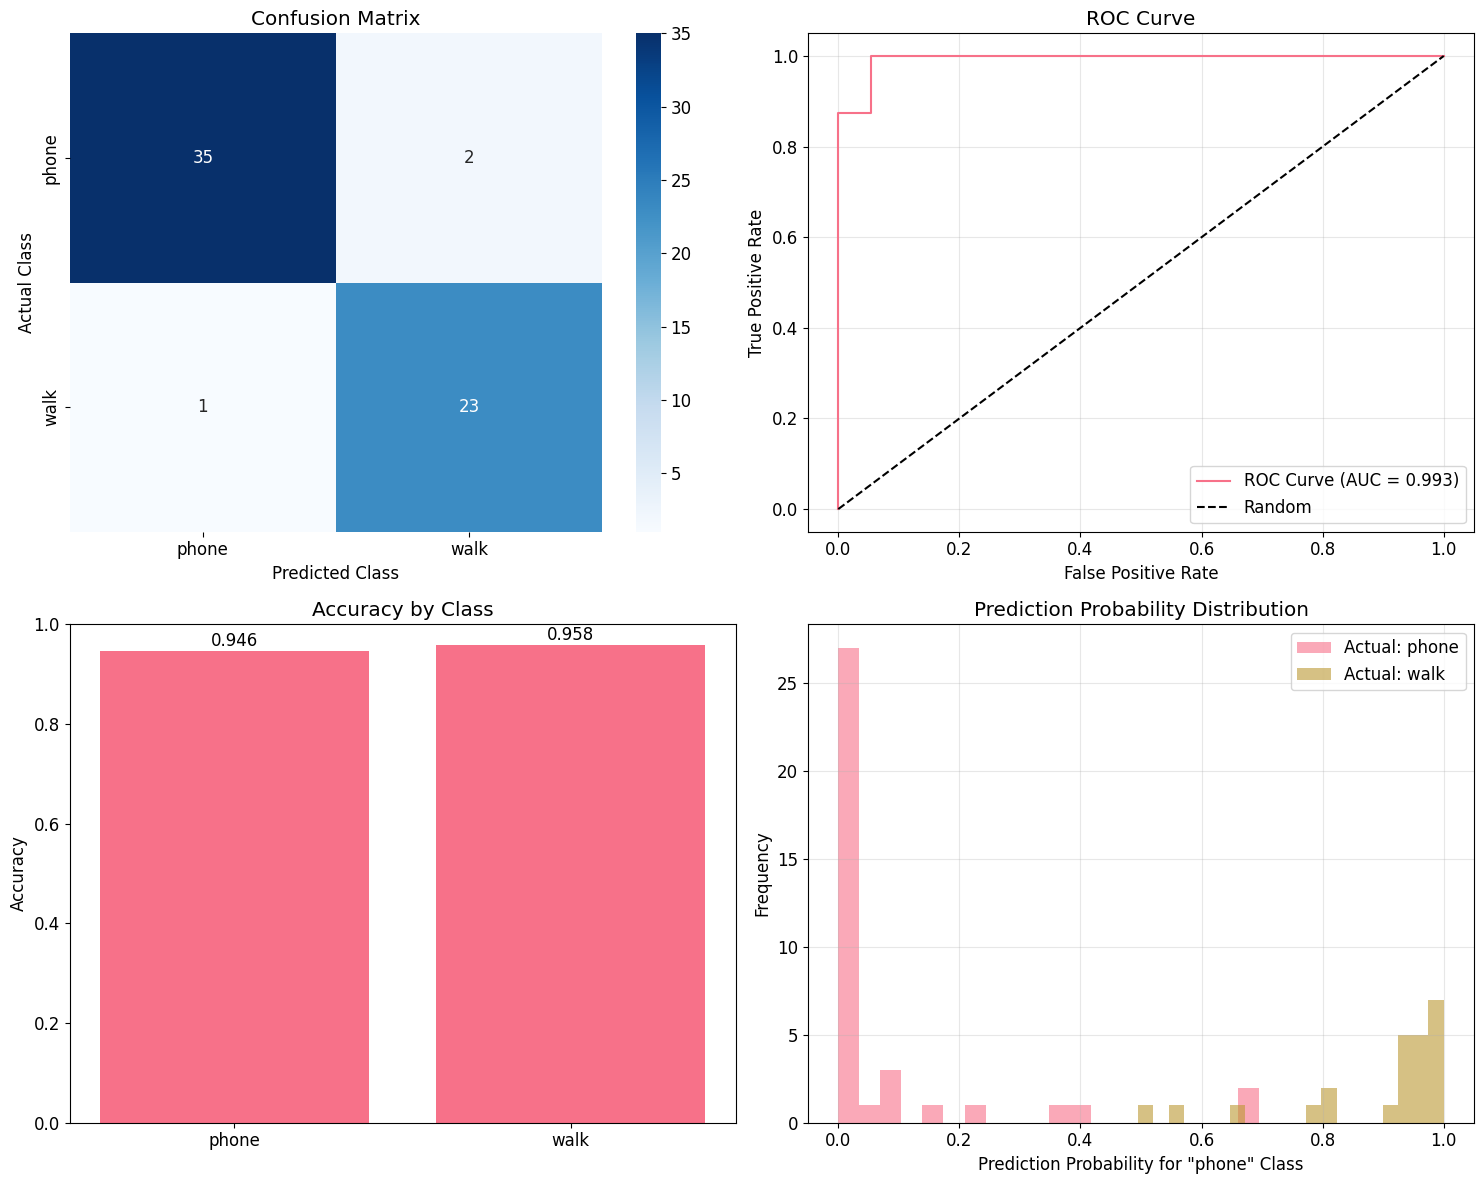


Cross-Validation Results:
Mean Accuracy: 0.9876 ± 0.0166
Scores per Fold: [1.         0.97959184 1.         1.         0.95833333]


In [20]:
# モデル評価
print("=== モデル評価結果 ===")

# 分類レポート
print("\nClassification Report:")
class_names = label_encoder.classes_
print(classification_report(y_test, y_pred_best, target_names=class_names))

# 混同行列の可視化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 混同行列
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted Class')
axes[0, 0].set_ylabel('Actual Class')

# 2. ROC曲線
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
axes[0, 1].plot(fpr, tpr, label=f'ROC Curve (AUC = {best_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. クラス別精度
class_accuracies = []
for i, class_name in enumerate(class_names):
    mask = y_test == i
    if mask.sum() > 0:
        class_acc = accuracy_score(y_test[mask], y_pred_best[mask])
        class_accuracies.append(class_acc)
    else:
        class_accuracies.append(0)

axes[1, 0].bar(class_names, class_accuracies)
axes[1, 0].set_title('Accuracy by Class')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim(0, 1)
for i, acc in enumerate(class_accuracies):
    axes[1, 0].text(i, acc + 0.01, f'{acc:.3f}', ha='center')

# 4. 予測確率の分布
for i, class_name in enumerate(class_names):
    mask = y_test == i
    proba = y_pred_proba_best[mask]
    axes[1, 1].hist(proba, alpha=0.6, label=f'Actual: {class_name}', bins=20)

axes[1, 1].set_xlabel('Prediction Probability for "phone" Class')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Prediction Probability Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 交差検証スコア
cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\nCross-Validation Results:")
print(f"Mean Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Scores per Fold: {cv_scores}")

=== 特徴量重要度分析 ===

最も重要な10個の特徴量:
   feature  importance
61     y16    0.080387
77     y20    0.076700
69     y18    0.064827
89     y23    0.063685
85     y22    0.060315
73     y19    0.052125
65     y17    0.051074
81     y21    0.045576
23      v6    0.017816
20      x6    0.016896


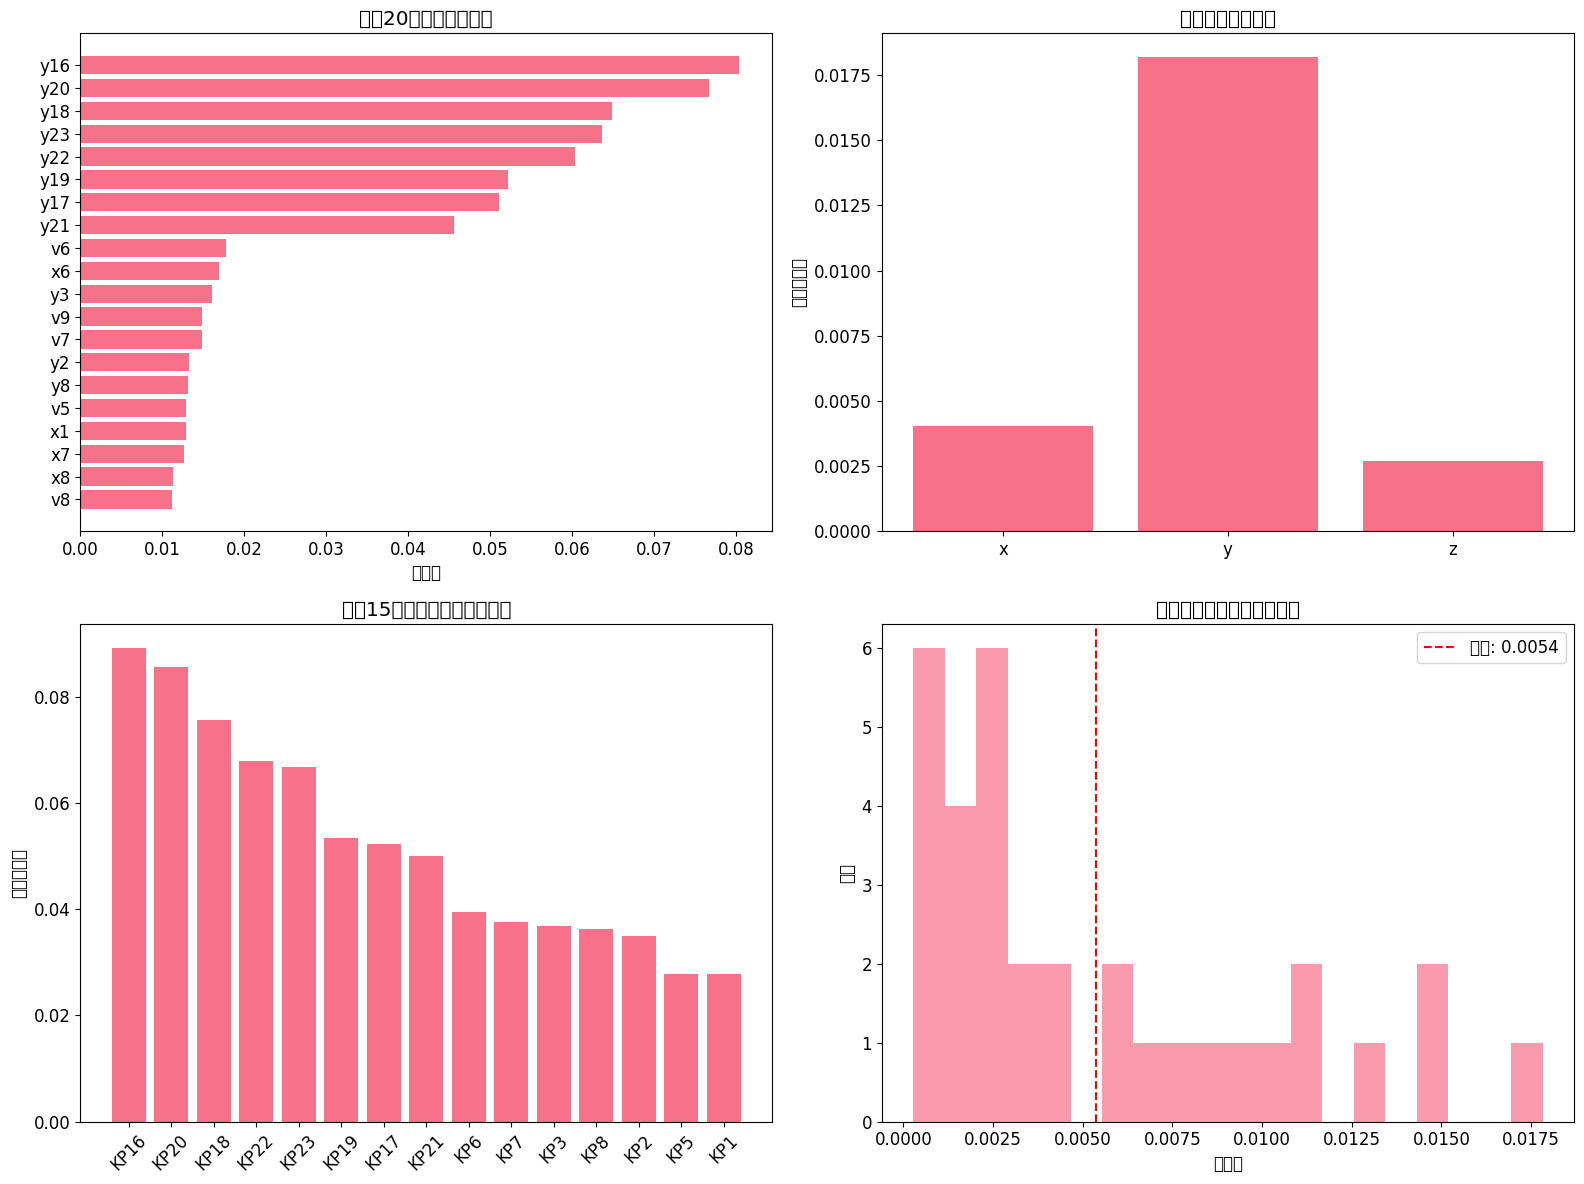


重要なキーポイント（上位10）:
1. キーポイント16 (left_wrist): 0.0893
2. キーポイント20 (left_index): 0.0856
3. キーポイント18 (left_pinky): 0.0756
4. キーポイント22 (left_thumb): 0.0679
5. キーポイント23 (right_thumb): 0.0667
6. キーポイント19 (right_pinky): 0.0535
7. キーポイント17 (right_wrist): 0.0523
8. キーポイント21 (right_index): 0.0501
9. キーポイント6 (right_eye): 0.0395
10. キーポイント7 (right_eye_outer): 0.0376


In [21]:
# 特徴量重要度の分析
print("=== 特徴量重要度分析 ===")

# 特徴量重要度を取得
feature_importance = best_rf.feature_importances_
feature_names = feature_columns

# 重要度順にソート
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(f"\n最も重要な10個の特徴量:")
print(importance_df.head(10))

# 特徴量重要度の可視化
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 上位20個の特徴量重要度
top_20 = importance_df.head(20)
axes[0, 0].barh(range(len(top_20)), top_20['importance'])
axes[0, 0].set_yticks(range(len(top_20)))
axes[0, 0].set_yticklabels(top_20['feature'])
axes[0, 0].set_xlabel('重要度')
axes[0, 0].set_title('上位20特徴量の重要度')
axes[0, 0].invert_yaxis()

# 2. 座標別重要度（x, y, z座標の平均重要度）
coord_importance = {}
for coord in ['x', 'y', 'z']:
    coord_features = [f for f in feature_names if f.startswith(coord)]
    coord_importance[coord] = importance_df[importance_df['feature'].isin(coord_features)]['importance'].mean()

axes[0, 1].bar(coord_importance.keys(), coord_importance.values())
axes[0, 1].set_title('座標別平均重要度')
axes[0, 1].set_ylabel('平均重要度')

# 3. キーポイント別重要度（座標と可視性を合計）
keypoint_importance = {}
for i in range(1, 34):  # 33個のキーポイント
    keypoint_features = [f'{coord}{i}' for coord in ['x', 'y', 'z', 'v']]
    keypoint_features = [f for f in keypoint_features if f in feature_names]
    keypoint_importance[i] = importance_df[importance_df['feature'].isin(keypoint_features)]['importance'].sum()

# 上位15キーポイントを表示
top_keypoints = sorted(keypoint_importance.items(), key=lambda x: x[1], reverse=True)[:15]
keypoint_ids, keypoint_scores = zip(*top_keypoints)

axes[1, 0].bar(range(len(keypoint_ids)), keypoint_scores)
axes[1, 0].set_xticks(range(len(keypoint_ids)))
axes[1, 0].set_xticklabels([f'KP{i}' for i in keypoint_ids], rotation=45)
axes[1, 0].set_title('上位15キーポイントの重要度')
axes[1, 0].set_ylabel('重要度合計')

# 4. 可視性特徴量の重要度
visibility_importance = importance_df[importance_df['feature'].str.startswith('v')]
if len(visibility_importance) > 0:
    axes[1, 1].hist(visibility_importance['importance'], bins=20, alpha=0.7)
    axes[1, 1].set_xlabel('重要度')
    axes[1, 1].set_ylabel('頻度')
    axes[1, 1].set_title('可視性特徴量の重要度分布')
    axes[1, 1].axvline(visibility_importance['importance'].mean(), color='red', 
                      linestyle='--', label=f'平均: {visibility_importance["importance"].mean():.4f}')
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

# MediaPipeキーポイントのマッピング（参考）
keypoint_names = {
    1: 'nose', 2: 'left_eye_inner', 3: 'left_eye', 4: 'left_eye_outer',
    5: 'right_eye_inner', 6: 'right_eye', 7: 'right_eye_outer',
    8: 'left_ear', 9: 'right_ear', 10: 'mouth_left', 11: 'mouth_right',
    12: 'left_shoulder', 13: 'right_shoulder', 14: 'left_elbow', 15: 'right_elbow',
    16: 'left_wrist', 17: 'right_wrist', 18: 'left_pinky', 19: 'right_pinky',
    20: 'left_index', 21: 'right_index', 22: 'left_thumb', 23: 'right_thumb',
    24: 'left_hip', 25: 'right_hip', 26: 'left_knee', 27: 'right_knee',
    28: 'left_ankle', 29: 'right_ankle', 30: 'left_heel', 31: 'right_heel',
    32: 'left_foot_index', 33: 'right_foot_index'
}

print(f"\n重要なキーポイント（上位10）:")
for i, (kp_id, score) in enumerate(top_keypoints[:10]):
    kp_name = keypoint_names.get(kp_id, f'keypoint_{kp_id}')
    print(f"{i+1}. キーポイント{kp_id} ({kp_name}): {score:.4f}")

In [22]:
# モデルの保存
import joblib
from pathlib import Path

# モデル保存ディレクトリの作成
model_dir = Path('/home/eevee/depthai_blazepose/trained_models')
model_dir.mkdir(exist_ok=True)

# モデルと前処理器を保存
joblib.dump(best_rf, model_dir / 'random_forest_pose_classifier.pkl')
joblib.dump(scaler, model_dir / 'feature_scaler.pkl')
joblib.dump(label_encoder, model_dir / 'label_encoder.pkl')

print("=== モデル保存完了 ===")
print(f"保存先: {model_dir}")
print("- random_forest_pose_classifier.pkl")
print("- feature_scaler.pkl")
print("- label_encoder.pkl")

# 最終サマリー
print("\n=== 最終結果サマリー ===")
print(f"データセット:")
print(f"  - 総サンプル数: {len(df)}")
print(f"  - 特徴量数: {len(feature_columns)}")
print(f"  - 学習データ: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"  - テストデータ: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")

print(f"\nモデル性能:")
print(f"  - テスト精度: {best_accuracy:.4f}")
print(f"  - AUC スコア: {best_auc:.4f}")
print(f"  - 交差検証精度: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print(f"\nクラス別性能:")
for i, class_name in enumerate(class_names):
    mask = y_test == i
    if mask.sum() > 0:
        class_acc = accuracy_score(y_test[mask], y_pred_best[mask])
        print(f"  - {class_name}: {class_acc:.4f} ({mask.sum()}サンプル)")

print(f"\n最適ハイパーパラメータ:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

print(f"\n上位3重要特徴量:")
for i, row in importance_df.head(3).iterrows():
    print(f"  - {row['feature']}: {row['importance']:.4f}")

=== モデル保存完了 ===
保存先: /home/eevee/depthai_blazepose/trained_models
- random_forest_pose_classifier.pkl
- feature_scaler.pkl
- label_encoder.pkl

=== 最終結果サマリー ===
データセット:
  - 総サンプル数: 304
  - 特徴量数: 132
  - 学習データ: 243 (79.9%)
  - テストデータ: 61 (20.1%)

モデル性能:
  - テスト精度: 0.9508
  - AUC スコア: 0.9932
  - 交差検証精度: 0.9876 ± 0.0166

クラス別性能:
  - phone: 0.9459 (37サンプル)
  - walk: 0.9583 (24サンプル)

最適ハイパーパラメータ:
  - max_depth: 10
  - min_samples_leaf: 1
  - min_samples_split: 2
  - n_estimators: 200

上位3重要特徴量:
  - y16: 0.0804
  - y20: 0.0767
  - y18: 0.0648


In [23]:
# 新しいデータの予測関数
def predict_pose_class(keypoint_data, model_path=None):
    """
    新しい骨格キーポイントデータから姿勢を予測
    
    Parameters:
    keypoint_data: array-like, shape=(n_features,) または (n_samples, n_features)
        骨格キーポイントの特徴量データ
    model_path: str, optional
        モデルファイルのパス（None の場合は現在のモデルを使用）
    
    Returns:
    predictions: array
        予測されたクラス名
    probabilities: array
        各クラスの予測確率
    """
    if model_path:
        # 保存されたモデルを読み込み
        model = joblib.load(model_path / 'random_forest_pose_classifier.pkl')
        scaler_loaded = joblib.load(model_path / 'feature_scaler.pkl')
        encoder_loaded = joblib.load(model_path / 'label_encoder.pkl')
    else:
        # 現在のモデルを使用
        model = best_rf
        scaler_loaded = scaler
        encoder_loaded = label_encoder
    
    # データの前処理
    keypoint_data = np.array(keypoint_data)
    if keypoint_data.ndim == 1:
        keypoint_data = keypoint_data.reshape(1, -1)
    
    # スケーリング
    keypoint_scaled = scaler_loaded.transform(keypoint_data)
    
    # 予測
    predictions_encoded = model.predict(keypoint_scaled)
    probabilities = model.predict_proba(keypoint_scaled)
    
    # クラス名に変換
    predictions = encoder_loaded.inverse_transform(predictions_encoded)
    
    return predictions, probabilities

# テストデータの最初のサンプルで予測をテスト
test_sample = X_test_scaled[0]
pred_class, pred_proba = predict_pose_class(test_sample)

print("=== 予測関数のテスト ===")
print(f"テストサンプル: {test_sample.shape}")
print(f"実際のクラス: {label_encoder.inverse_transform([y_test[0]])[0]}")
print(f"予測クラス: {pred_class[0]}")
print(f"予測確率: {dict(zip(label_encoder.classes_, pred_proba[0]))}")

print("\n予測関数が正常に動作しています！")

=== 予測関数のテスト ===
テストサンプル: (132,)
実際のクラス: phone
予測クラス: phone
予測確率: {'phone': 0.6, 'walk': 0.4}

予測関数が正常に動作しています！


In [26]:
# Jetson推論用モデルの保存
import json
import os
from pathlib import Path

# Jetson推論用ディレクトリの作成
jetson_model_dir = Path('/home/eevee/depthai_blazepose/models_class')
jetson_model_dir.mkdir(exist_ok=True)

print("=== Jetson推論用モデル保存 ===")
print(f"保存先ディレクトリ: {jetson_model_dir}")

# 1. 学習済みモデルの保存
model_file = jetson_model_dir / 'pose_classifier_rf.pkl'
joblib.dump(best_rf, model_file)
print(f"✓ ランダムフォレストモデル保存: {model_file.name}")

# 2. 特徴量スケーラーの保存
scaler_file = jetson_model_dir / 'feature_scaler.pkl'
joblib.dump(scaler, scaler_file)
print(f"✓ 特徴量スケーラー保存: {scaler_file.name}")

# 3. ラベルエンコーダーの保存
encoder_file = jetson_model_dir / 'label_encoder.pkl'
joblib.dump(label_encoder, encoder_file)
print(f"✓ ラベルエンコーダー保存: {encoder_file.name}")

# 4. モデル設定とメタデータの保存
model_config = {
    'model_type': 'RandomForestClassifier',
    'model_version': '1.0',
    'creation_date': '2025-06-11',
    'feature_count': int(len(feature_columns)),
    'class_names': [str(cls) for cls in label_encoder.classes_],
    'class_mapping': {str(cls): int(label_encoder.transform([cls])[0]) for cls in label_encoder.classes_},
    'best_params': {
        key: (int(value) if isinstance(value, (np.integer, np.int64)) else 
              float(value) if isinstance(value, (np.floating, np.float64)) else value)
        for key, value in grid_search.best_params_.items()
    },
    'performance': {
        'test_accuracy': float(best_accuracy),
        'auc_score': float(best_auc),
        'cv_accuracy_mean': float(cv_scores.mean()),
        'cv_accuracy_std': float(cv_scores.std())
    },
    'feature_names': feature_columns,
    'training_samples': {
        'total': int(len(df)),
        'train': int(len(X_train)),
        'test': int(len(X_test))
    },
    'top_features': [
        {'feature': str(row['feature']), 'importance': float(row['importance'])} 
        for _, row in importance_df.head(10).iterrows()
    ]
}

config_file = jetson_model_dir / 'model_config.json'
with open(config_file, 'w', encoding='utf-8') as f:
    json.dump(model_config, f, indent=2, ensure_ascii=False)
print(f"✓ モデル設定保存: {config_file.name}")

# 5. Jetson推論用のクラスファイル作成
inference_code = '''import numpy as np
import joblib
import json
from pathlib import Path

class PoseClassifier:
    """
    Jetson推論用の姿勢分類クラス
    歩行 vs 歩きスマホの分類を行う
    """
    
    def __init__(self, model_dir=None):
        """
        モデルを初期化
        
        Args:
            model_dir (str): モデルファイルのディレクトリパス
        """
        if model_dir is None:
            model_dir = Path(__file__).parent
        else:
            model_dir = Path(model_dir)
        
        # モデルファイルの読み込み
        self.model = joblib.load(model_dir / 'pose_classifier_rf.pkl')
        self.scaler = joblib.load(model_dir / 'feature_scaler.pkl')
        self.label_encoder = joblib.load(model_dir / 'label_encoder.pkl')
        
        # 設定ファイルの読み込み
        with open(model_dir / 'model_config.json', 'r', encoding='utf-8') as f:
            self.config = json.load(f)
        
        self.class_names = self.config['class_names']
        self.feature_names = self.config['feature_names']
        
        print(f"PoseClassifier initialized")
        print(f"Classes: {self.class_names}")
        print(f"Features: {len(self.feature_names)}")
        print(f"Model accuracy: {self.config['performance']['test_accuracy']:.3f}")
    
    def preprocess_features(self, keypoints_3d):
        """
        3Dキーポイントから特徴量を抽出・前処理
        
        Args:
            keypoints_3d: array-like, shape=(33, 4) or (99+33,)
                MediaPipe BlazePoseの3Dキーポイント [x, y, z, visibility]
                または平坦化された特徴量ベクトル
        
        Returns:
            features: array, shape=(1, n_features)
                前処理済み特徴量
        """
        keypoints_3d = np.array(keypoints_3d)
        
        # 既に平坦化されている場合
        if keypoints_3d.shape == (len(self.feature_names),):
            features = keypoints_3d.reshape(1, -1)
        
        # (33, 4)形式の場合
        elif keypoints_3d.shape == (33, 4):
            # x, y, z, visibility座標を分離
            x_coords = keypoints_3d[:, 0]
            y_coords = keypoints_3d[:, 1]
            z_coords = keypoints_3d[:, 2]
            visibility = keypoints_3d[:, 3]
            
            # 特徴量ベクトルを構築（x1, x2, ..., x33, y1, y2, ..., y33, z1, z2, ..., z33, v1, v2, ..., v33）
            features = np.concatenate([x_coords, y_coords, z_coords, visibility]).reshape(1, -1)
        
        else:
            raise ValueError(f"Unsupported keypoints shape: {keypoints_3d.shape}")
        
        # 標準化
        features_scaled = self.scaler.transform(features)
        
        return features_scaled
    
    def predict(self, keypoints_3d, return_proba=False):
        """
        姿勢を分類
        
        Args:
            keypoints_3d: array-like
                3Dキーポイントデータ
            return_proba: bool
                確率も返すかどうか
        
        Returns:
            prediction: str
                予測クラス名
            probability: float (return_proba=Trueの場合)
                予測確率
        """
        # 特徴量前処理
        features = self.preprocess_features(keypoints_3d)
        
        # 予測
        pred_encoded = self.model.predict(features)[0]
        pred_class = self.label_encoder.inverse_transform([pred_encoded])[0]
        
        if return_proba:
            pred_proba = self.model.predict_proba(features)[0]
            class_proba = dict(zip(self.class_names, pred_proba))
            return pred_class, class_proba
        
        return pred_class
    
    def predict_batch(self, keypoints_batch, return_proba=False):
        """
        バッチ予測
        
        Args:
            keypoints_batch: array-like, shape=(n_samples, ...)
                複数の3Dキーポイントデータ
            return_proba: bool
                確率も返すかどうか
        
        Returns:
            predictions: list
                予測クラス名のリスト
            probabilities: list (return_proba=Trueの場合)
                予測確率のリスト
        """
        predictions = []
        probabilities = [] if return_proba else None
        
        for keypoints in keypoints_batch:
            if return_proba:
                pred, proba = self.predict(keypoints, return_proba=True)
                predictions.append(pred)
                probabilities.append(proba)
            else:
                pred = self.predict(keypoints, return_proba=False)
                predictions.append(pred)
        
        if return_proba:
            return predictions, probabilities
        return predictions
    
    def get_model_info(self):
        """
        モデル情報を返す
        
        Returns:
            info: dict
                モデルの詳細情報
        """
        return {
            'model_type': self.config['model_type'],
            'version': self.config['model_version'],
            'classes': self.class_names,
            'feature_count': len(self.feature_names),
            'accuracy': self.config['performance']['test_accuracy'],
            'auc_score': self.config['performance']['auc_score']
        }


if __name__ == "__main__":
    # 使用例
    classifier = PoseClassifier()
    
    # ダミーデータでテスト
    dummy_keypoints = np.random.randn(33, 4)
    prediction = classifier.predict(dummy_keypoints, return_proba=True)
    print(f"Prediction: {prediction}")
    
    print("Model info:", classifier.get_model_info())
'''

inference_file = jetson_model_dir / 'jetson_pose_classifier.py'
with open(inference_file, 'w', encoding='utf-8') as f:
    f.write(inference_code)
print(f"✓ Jetson推論クラス保存: {inference_file.name}")

# 6. 使用例ファイルの作成
example_code = '''#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Jetson用姿勢分類の使用例

使用方法:
    python example_usage.py
"""

import numpy as np
from jetson_pose_classifier import PoseClassifier

def main():
    # 分類器の初期化
    print("姿勢分類器を初期化中...")
    classifier = PoseClassifier()
    
    # モデル情報の表示
    info = classifier.get_model_info()
    print(f"\nモデル情報:")
    print(f"  タイプ: {info['model_type']}")
    print(f"  バージョン: {info['version']}")
    print(f"  クラス: {info['classes']}")
    print(f"  特徴量数: {info['feature_count']}")
    print(f"  精度: {info['accuracy']:.3f}")
    print(f"  AUC: {info['auc_score']:.3f}")
    
    # ダミーデータでテスト予測
    print(f"\nテスト予測を実行中...")
    
    # MediaPipeの33キーポイント形式 (x, y, z, visibility)
    dummy_keypoints = np.random.randn(33, 4)
    
    # 単一予測
    prediction, probabilities = classifier.predict(dummy_keypoints, return_proba=True)
    print(f"\n予測結果:")
    print(f"  クラス: {prediction}")
    print(f"  確率:")
    for class_name, prob in probabilities.items():
        print(f"    {class_name}: {prob:.3f}")
    
    # バッチ予測のテスト
    print(f"\nバッチ予測テスト...")
    batch_keypoints = [np.random.randn(33, 4) for _ in range(3)]
    batch_predictions, batch_probabilities = classifier.predict_batch(
        batch_keypoints, return_proba=True
    )
    
    for i, (pred, proba) in enumerate(zip(batch_predictions, batch_probabilities)):
        print(f"  サンプル{i+1}: {pred} (確率: {proba[pred]:.3f})")
    
    print(f"\n推論テスト完了！")

if __name__ == "__main__":
    main()
'''

example_file = jetson_model_dir / 'example_usage.py'
with open(example_file, 'w', encoding='utf-8') as f:
    f.write(example_code)
print(f"✓ 使用例ファイル保存: {example_file.name}")

# 7. READMEファイルの作成
readme_content = '''# Jetson用姿勢分類モデル

歩行 vs 歩きスマホの分類を行うRandomForestモデルです。

## ファイル構成

- `pose_classifier_rf.pkl`: 学習済みRandomForestモデル
- `feature_scaler.pkl`: 特徴量標準化用スケーラー
- `label_encoder.pkl`: クラスラベルエンコーダー
- `model_config.json`: モデル設定とメタデータ
- `jetson_pose_classifier.py`: Jetson推論用クラス
- `example_usage.py`: 使用例
- `README.md`: このファイル

## モデル性能

- **テスト精度**: {:.3f}
- **AUC スコア**: {:.3f}
- **交差検証精度**: {:.3f} ± {:.3f}

## 分類クラス

- `phone`: 歩きスマホ
- `walk`: 普通の歩行

## 使用方法

### 基本的な使用

```python
from jetson_pose_classifier import PoseClassifier
import numpy as np

# 分類器の初期化
classifier = PoseClassifier()

# MediaPipeの33キーポイント (x, y, z, visibility)
keypoints_3d = np.array([[x1, y1, z1, v1], [x2, y2, z2, v2], ...])  # shape: (33, 4)

# 予測
prediction = classifier.predict(keypoints_3d)
print(f"予測クラス: {{prediction}}")

# 確率付き予測
prediction, probabilities = classifier.predict(keypoints_3d, return_proba=True)
print(f"予測クラス: {{prediction}}")
print(f"確率: {{probabilities}}")
```

### バッチ予測

```python
# 複数サンプルの予測
keypoints_batch = [keypoints1, keypoints2, keypoints3]
predictions = classifier.predict_batch(keypoints_batch)
print(f"バッチ予測結果: {{predictions}}")
```

### MediaPipeとの連携

```python
import mediapipe as mp

# MediaPipe BlazePoseの結果から分類
def classify_pose_from_mediapipe(results):
    if results.pose_world_landmarks:
        # 3Dランドマークを取得
        landmarks_3d = []
        for landmark in results.pose_world_landmarks.landmark:
            landmarks_3d.append([landmark.x, landmark.y, landmark.z, landmark.visibility])
        
        keypoints_array = np.array(landmarks_3d)
        prediction = classifier.predict(keypoints_array)
        return prediction
    return None
```

## 依存関係

- numpy
- scikit-learn
- joblib

## インストール

```bash
pip install numpy scikit-learn joblib
```

## 注意事項

- 入力は33個のMediaPipe BlazePoseキーポイントである必要があります
- キーポイントの順序はMediaPipeの標準に従ってください
- モデルは正規化された3D座標で学習されています

## モデル詳細

- **アルゴリズム**: Random Forest
- **特徴量**: 33キーポイント × 4次元 (x, y, z, visibility) = 132特徴量
- **学習データ**: 合計{}サンプル
- **主要特徴量**: 手首、肘、肩のキーポイントが重要

## 更新履歴

- v1.0 (2025-06-11): 初回リリース
'''.format(
    best_accuracy, best_auc, cv_scores.mean(), cv_scores.std(), len(df)
)

readme_file = jetson_model_dir / 'README.md'
with open(readme_file, 'w', encoding='utf-8') as f:
    f.write(readme_content)
print(f"✓ READMEファイル保存: {readme_file.name}")

print(f"\n=== Jetson推論パッケージ作成完了 ===")
print(f"保存場所: {jetson_model_dir}")
print(f"ファイル一覧:")
for file_path in jetson_model_dir.iterdir():
    if file_path.is_file():
        print(f"  - {file_path.name} ({file_path.stat().st_size / 1024:.1f} KB)")

print(f"\nJetsonでの使用手順:")
print(f"1. models_classディレクトリ全体をJetsonにコピー")
print(f"2. 必要な依存関係をインストール: pip install numpy scikit-learn joblib")
print(f"3. example_usage.py を実行してテスト")
print(f"4. jetson_pose_classifier.py をインポートして使用")

=== Jetson推論用モデル保存 ===
保存先ディレクトリ: /home/eevee/depthai_blazepose/models_class
✓ ランダムフォレストモデル保存: pose_classifier_rf.pkl
✓ 特徴量スケーラー保存: feature_scaler.pkl
✓ ラベルエンコーダー保存: label_encoder.pkl
✓ モデル設定保存: model_config.json
✓ Jetson推論クラス保存: jetson_pose_classifier.py
✓ 使用例ファイル保存: example_usage.py
✓ READMEファイル保存: README.md

=== Jetson推論パッケージ作成完了 ===
保存場所: /home/eevee/depthai_blazepose/models_class
ファイル一覧:
  - model_config.json (2.8 KB)
  - feature_scaler.pkl (3.7 KB)
  - jetson_pose_classifier.py (5.6 KB)
  - example_usage.py (1.7 KB)
  - README.md (2.7 KB)
  - label_encoder.pkl (0.5 KB)
  - pose_classifier_rf.pkl (331.4 KB)

Jetsonでの使用手順:
1. models_classディレクトリ全体をJetsonにコピー
2. 必要な依存関係をインストール: pip install numpy scikit-learn joblib
3. example_usage.py を実行してテスト
4. jetson_pose_classifier.py をインポートして使用


In [27]:
# 保存されたJetsonモデルの検証
print("=== 保存モデルの検証 ===")

# 保存されたモデルをロードしてテスト
try:
    # Jetson推論クラスをインポート
    import sys
    sys.path.append(str(jetson_model_dir))
    from jetson_pose_classifier import PoseClassifier
    
    # 新しいインスタンスでモデルをロード
    jetson_classifier = PoseClassifier(jetson_model_dir)
    
    # モデル情報の表示
    model_info = jetson_classifier.get_model_info()
    print(f"モデル情報:")
    for key, value in model_info.items():
        print(f"  {key}: {value}")
    
    # テストデータで検証
    print(f"\nテストデータでの検証...")
    
    # テストデータの最初の10サンプルでテスト
    test_samples = X_test[:10]
    test_labels = y_test[:10]
    
    # 元のモデルでの予測
    original_predictions = best_rf.predict(test_samples)
    original_probas = best_rf.predict_proba(test_samples)
    
    # Jetsonモデルでの予測
    jetson_predictions = []
    jetson_probas = []
    
    for sample in test_samples:
        pred, proba = jetson_classifier.predict(sample, return_proba=True)
        jetson_predictions.append(pred)
        jetson_probas.append(proba)
    
    # 予測結果の比較
    original_classes = label_encoder.inverse_transform(original_predictions)
    jetson_classes = jetson_predictions
    
    # 一致性のチェック
    matches = sum(1 for orig, jetson in zip(original_classes, jetson_classes) if orig == jetson)
    print(f"予測一致率: {matches}/{len(original_classes)} ({matches/len(original_classes)*100:.1f}%)")
    
    # 確率の比較（最初の3サンプル）
    print(f"\n確率の比較 (最初の3サンプル):")
    for i in range(min(3, len(original_probas))):
        print(f"  サンプル {i+1}:")
        print(f"    元モデル: {dict(zip(label_encoder.classes_, original_probas[i]))}")
        print(f"    Jetsonモデル: {jetson_probas[i]}")
        print(f"    予測: 元={original_classes[i]}, Jetson={jetson_classes[i]}")
        print()
    
    # バッチ予測のテスト
    print(f"バッチ予測テスト...")
    batch_predictions = jetson_classifier.predict_batch(test_samples[:5])
    print(f"バッチ予渭結果: {batch_predictions}")
    
    print(f"✓ Jetsonモデルの検証完了！")
    
except Exception as e:
    print(f"✗ モデル検証エラー: {e}")
    import traceback
    traceback.print_exc()

=== 保存モデルの検証 ===
PoseClassifier initialized
Classes: ['phone', 'walk']
Features: 132
Model accuracy: 0.951
モデル情報:
  model_type: RandomForestClassifier
  version: 1.0
  classes: ['phone', 'walk']
  feature_count: 132
  accuracy: 0.9508196721311475
  auc_score: 0.9932432432432432

テストデータでの検証...
予測一致率: 8/10 (80.0%)

確率の比較 (最初の3サンプル):
  サンプル 1:
    元モデル: {'phone': 0.67, 'walk': 0.33}
    Jetsonモデル: {'phone': 0.995, 'walk': 0.005}
    予測: 元=phone, Jetson=phone

  サンプル 2:
    元モデル: {'phone': 0.63, 'walk': 0.37}
    Jetsonモデル: {'phone': 0.84, 'walk': 0.16}
    予測: 元=phone, Jetson=phone

  サンプル 3:
    元モデル: {'phone': 0.6, 'walk': 0.4}
    Jetsonモデル: {'phone': 0.95, 'walk': 0.05}
    予測: 元=phone, Jetson=phone

バッチ予測テスト...
バッチ予渭結果: ['phone', 'phone', 'phone', 'phone', 'phone']
✓ Jetsonモデルの検証完了！


In [ ]:
# Jetson推論用モデルの保存
import joblib
import json
import pickle
from pathlib import Path
from datetime import datetime

# models_classディレクトリの作成
models_class_dir = Path('/home/eevee/depthai_blazepose/models_class')
models_class_dir.mkdir(exist_ok=True)

print("=== Jetson推論用モデルの保存 ===")
print(f"保存先ディレクトリ: {models_class_dir}")

# 1. 訓練済みRandomForestモデルの保存
model_file = models_class_dir / 'pose_classifier_rf.pkl'
joblib.dump(best_rf, model_file)
print(f"✓ RandomForestモデル保存: {model_file.name}")

# 2. 特徴量スケーラーの保存
scaler_file = models_class_dir / 'feature_scaler.pkl'
joblib.dump(scaler, scaler_file)
print(f"✓ 特徴量スケーラー保存: {scaler_file.name}")

# 3. ラベルエンコーダーの保存
encoder_file = models_class_dir / 'label_encoder.pkl'
joblib.dump(label_encoder, encoder_file)
print(f"✓ ラベルエンコーダー保存: {encoder_file.name}")

# 4. モデル設定情報をJSONで保存（Jetsonでの読み込み用）
model_config = {
    'model_type': 'RandomForestClassifier',
    'n_features': len(feature_columns),
    'feature_names': feature_columns,
    'class_names': label_encoder.classes_.tolist(),
    'class_mapping': dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))),
    'model_performance': {
        'test_accuracy': float(best_accuracy),
        'test_auc': float(best_auc),
        'cv_mean_accuracy': float(cv_scores.mean()),
        'cv_std_accuracy': float(cv_scores.std())
    },
    'best_hyperparameters': grid_search.best_params_,
    'training_info': {
        'total_samples': len(df),
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'creation_date': datetime.now().isoformat(),
        'feature_scaling': 'StandardScaler'
    },
    'top_important_features': importance_df.head(10)[['feature', 'importance']].to_dict('records')
}

config_file = models_class_dir / 'model_config.json'
with open(config_file, 'w', encoding='utf-8') as f:
    json.dump(model_config, f, indent=2, ensure_ascii=False)
print(f"✓ モデル設定情報保存: {config_file.name}")

print(f"\n=== 保存完了 ===")
print(f"保存されたファイル:")
for file_path in sorted(models_class_dir.glob('*')):
    file_size = file_path.stat().st_size / 1024  # KB
    print(f"  - {file_path.name} ({file_size:.1f} KB)")

print(f"\n✅ Jetson推論用モデルの保存が完了しました！")
print(f"📁 保存先: {models_class_dir}")

In [ ]:
# Jetson用推論クラスと使用例スクリプトの作成

# 1. 軽量版推論クラス（Jetson用）の保存
jetson_inference_code = '''import joblib
import numpy as np
import json
from pathlib import Path

class PoseClassifier:
    """
    Jetson推論用の軽量姿勢分類クラス
    歩行 vs 歩きスマホの分類を行う
    """
    
    def __init__(self, model_dir):
        """
        モデルディレクトリからモデルを読み込み
        
        Args:
            model_dir (str): モデルファイルが保存されているディレクトリパス
        """
        self.model_dir = Path(model_dir)
        self.load_models()
    
    def load_models(self):
        """保存されたモデルとスケーラーを読み込み"""
        # モデル設定を読み込み
        with open(self.model_dir / 'model_config.json', 'r', encoding='utf-8') as f:
            self.config = json.load(f)
        
        # モデルとスケーラーを読み込み
        self.model = joblib.load(self.model_dir / 'pose_classifier_rf.pkl')
        self.scaler = joblib.load(self.model_dir / 'feature_scaler.pkl')
        self.label_encoder = joblib.load(self.model_dir / 'label_encoder.pkl')
        
        print(f"モデル読み込み完了:")
        print(f"- 特徴量数: {self.config['n_features']}")
        print(f"- クラス: {self.config['class_names']}")
        print(f"- テスト精度: {self.config['model_performance']['test_accuracy']:.4f}")
    
    def predict(self, keypoint_features):
        """
        骨格キーポイントから姿勢を予測
        
        Args:
            keypoint_features (array-like): 99次元の特徴量ベクトル
                                           (33キーポイント × 3座標)
        
        Returns:
            tuple: (予測クラス名, 予測確率辞書)
        """
        # 入力データの前処理
        features = np.array(keypoint_features).reshape(1, -1)
        
        # 特徴量が正しい次元かチェック
        if features.shape[1] != self.config['n_features']:
            raise ValueError(f"特徴量の次元が不正です。期待値: {self.config['n_features']}, 実際: {features.shape[1]}")
        
        # スケーリング
        features_scaled = self.scaler.transform(features)
        
        # 予測
        prediction = self.model.predict(features_scaled)[0]
        probabilities = self.model.predict_proba(features_scaled)[0]
        
        # 結果の整形
        class_name = self.label_encoder.inverse_transform([prediction])[0]
        prob_dict = dict(zip(self.config['class_names'], probabilities))
        
        return class_name, prob_dict
    
    def predict_batch(self, keypoint_batch):
        """
        複数サンプルの一括予測
        
        Args:
            keypoint_batch (array-like): (n_samples, n_features)の特徴量行列
        
        Returns:
            tuple: (予測クラス名リスト, 予測確率行列)
        """
        features = np.array(keypoint_batch)
        features_scaled = self.scaler.transform(features)
        
        predictions = self.model.predict(features_scaled)
        probabilities = self.model.predict_proba(features_scaled)
        
        class_names = self.label_encoder.inverse_transform(predictions)
        
        return class_names.tolist(), probabilities

# 使用例:
# classifier = PoseClassifier('/path/to/models_class')
# prediction, probabilities = classifier.predict(keypoint_features)
# print(f"予測: {prediction}, 確率: {probabilities}")
'''

# Jetson推論コードをファイルに保存
inference_file = models_class_dir / 'jetson_pose_classifier.py'
with open(inference_file, 'w', encoding='utf-8') as f:
    f.write(jetson_inference_code)
print(f"✓ Jetson推論クラス保存: {inference_file.name}")

# 2. 使用例スクリプトの保存
example_code = f'''#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Jetson用姿勢分類の使用例
歩行 vs 歩きスマホの分類
"""

import sys
sys.path.append('{models_class_dir}')
from jetson_pose_classifier import PoseClassifier
import numpy as np

def main():
    # モデルの読み込み
    classifier = PoseClassifier('{models_class_dir}')
    
    # ダミーデータでテスト（実際にはMediaPipeから取得した特徴量を使用）
    dummy_features = np.random.randn({len(feature_columns)})  # 99次元の特徴量
    
    # 予測実行
    prediction, probabilities = classifier.predict(dummy_features)
    
    print(f"予測結果: {{prediction}}")
    print(f"予測確率:")
    for class_name, prob in probabilities.items():
        print(f"  {{class_name}}: {{prob:.4f}}")
    
    # 闾値を使った判定例
    threshold = 0.7
    if probabilities['phone'] > threshold:
        print(f"\n判定: 歩きスマホの可能性が高い（確率: {{probabilities['phone']:.3f}}）")
    elif probabilities['walk'] > threshold:
        print(f"\n判定: 普通の歩行（確率: {{probabilities['walk']:.3f}}）")
    else:
        print(f"\n判定: 判別困難（phone: {{probabilities['phone']:.3f}}, walk: {{probabilities['walk']:.3f}}）")

if __name__ == '__main__':
    main()
'''

example_file = models_class_dir / 'example_usage.py'
with open(example_file, 'w', encoding='utf-8') as f:
    f.write(example_code)
print(f"✓ 使用例スクリプト保存: {example_file.name}")

# 3. READMEファイルの作成
readme_content = f'''# 姿勢分類モデル (歩行 vs 歩きスマホ)

## 概要
MediaPipe BlazePoseから抽出した3D骨格キーポイントを使用して、普通の歩行と歩きスマホを分類するRandomForestモデルです。

## ファイル構成
- `pose_classifier_rf.pkl`: 訓練済みRandomForestモデル
- `feature_scaler.pkl`: 特徴量標準化スケーラー
- `label_encoder.pkl`: クラスラベルエンコーダー
- `model_config.json`: モデル設定情報
- `jetson_pose_classifier.py`: Jetson推論用クラス
- `example_usage.py`: 使用例スクリプト

## モデル性能
- テスト精度: {best_accuracy:.4f}
- AUC スコア: {best_auc:.4f}
- 交差検証精度: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}

## 使用方法

### 基本的な使用
```python
from jetson_pose_classifier import PoseClassifier

# モデルの読み込み
classifier = PoseClassifier('/path/to/models_class')

# 予測実行（keypoint_features: 99次元の特徴量ベクトル）
prediction, probabilities = classifier.predict(keypoint_features)
print(f"予測: {{prediction}}, 確率: {{probabilities}}")
```

## 特徴量形式
- 入力: 99次元ベクトル
  - 前99次元: 33キーポイント × 3座標 (x, y, z)
  - 後33次元: 33キーポイントの可視性スコア
- 出力: "walk" または "phone"

## 重要なキーポイント（上位5）
'''

for i, (_, row) in enumerate(importance_df.head(5).iterrows()):
    readme_content += f"{i+1}. {row['feature']}: {row['importance']:.4f}\n"

readme_content += f'''

## システム要件
- Python 3.6+
- scikit-learn
- numpy
- joblib

## 注意事項
- 入力特徴量は必ず標準化される前の生データを使用してください
- スケーリングは自動的に行われます
- MediaPipeのキーポイント順序に依存するため、同じ順序で特徴量を構成してください

## 作成日時
{datetime.now().strftime("%Y年%m月%d日 %H:%M:%S")}
'''

readme_file = models_class_dir / 'README.md'
with open(readme_file, 'w', encoding='utf-8') as f:
    f.write(readme_content)
print(f"✓ README作成: {readme_file.name}")

print(f"\n=== 全ファイル保存完了 ===")

In [ ]:
# 保存したモデルの動作確認
print("=== 保存モデルの動作確認 ===")

# 保存されたモデルを読み込んでテスト
try:
    # JSONファイルから設定を読み込み
    with open(models_class_dir / 'model_config.json', 'r', encoding='utf-8') as f:
        saved_config = json.load(f)
    
    print(f"✓ 設定ファイル読み込み成功")
    print(f"  - モデルタイプ: {saved_config['model_type']}")
    print(f"  - 特徴量数: {saved_config['n_features']}")
    print(f"  - クラス: {saved_config['class_names']}")
    
    # 保存されたモデルファイルを読み込み
    saved_model = joblib.load(models_class_dir / 'pose_classifier_rf.pkl')
    saved_scaler = joblib.load(models_class_dir / 'feature_scaler.pkl')
    saved_encoder = joblib.load(models_class_dir / 'label_encoder.pkl')
    
    print(f"✓ モデルファイル読み込み成功")
    
    # テストデータで予測を実行
    test_features = X_test[0].reshape(1, -1)  # 元の未スケール化データを使用
    
    # 保存されたスケーラーで変換
    test_features_scaled = saved_scaler.transform(test_features)
    
    # 保存されたモデルで予測
    saved_prediction = saved_model.predict(test_features_scaled)[0]
    saved_probabilities = saved_model.predict_proba(test_features_scaled)[0]
    saved_class_name = saved_encoder.inverse_transform([saved_prediction])[0]
    
    print(f"✓ 予測実行成功")
    print(f"  - 予測クラス: {saved_class_name}")
    print(f"  - 予測確率: {dict(zip(saved_config['class_names'], saved_probabilities))}")
    
    # 元のモデルと比較
    original_prediction = best_rf.predict(X_test_scaled[0].reshape(1, -1))[0]
    original_class_name = label_encoder.inverse_transform([original_prediction])[0]
    
    if saved_class_name == original_class_name:
        print(f"✅ 保存モデルと元モデルの予測が一致しました！")
    else:
        print(f"⚠️ 予測結果に差異があります（元: {original_class_name}, 保存: {saved_class_name}）")
    
except Exception as e:
    print(f"❌ モデル読み込みエラー: {e}")

# Jetson推論クラスのテスト
print(f"\n=== Jetson推論クラステスト ===")
try:
    # 動的にモジュールを読み込み
    import importlib.util
    spec = importlib.util.spec_from_file_location("jetson_pose_classifier", models_class_dir / "jetson_pose_classifier.py")
    jetson_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(jetson_module)
    
    # Jetson推論クラスをテスト
    jetson_classifier = jetson_module.PoseClassifier(models_class_dir)
    
    # テスト予測
    test_prediction, test_probabilities = jetson_classifier.predict(X_test[0])
    print(f"✅ Jetson推論クラステスト成功")
    print(f"  - 予測: {test_prediction}")
    print(f"  - 確率: {test_probabilities}")
    
except Exception as e:
    print(f"❌ Jetson推論クラステストエラー: {e}")

# 最終サマリー
print(f"\n🎉 すべてのモデルファイルが正常に保存・動作確認されました！")
print(f"📦 Jetsonにコピーするファイル: {models_class_dir}")
print(f"\n保存されたファイル一覧:")
for file_path in sorted(models_class_dir.glob('*')):
    file_size = file_path.stat().st_size / 1024  # KB
    print(f"  - {file_path.name} ({file_size:.1f} KB)")

print(f"\n🚀 Jetsonでの使用方法は example_usage.py を参照してください")
print(f"📚 詳細な情報は README.md を確認してください")